# Laplacian Blending, Harris and Hessian Corner Detection

### Importing the dataset and libraries

In [ ]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

# Downloading all the required libraries


# Importing all the required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import style
from glob import glob
from natsort import natsorted
from tqdm import tqdm
style.use('ggplot')

Mounted at /content/drive


In [ ]:
# Loading all the images in the drive
gt_images = []

for files in tqdm(natsorted(glob('/content/drive/My Drive/ES666CV/images/B/*'))):
    gt_images.append(cv2.imread(files, 1))

gt_images = np.array(gt_images) # Only possible because all images are of same size

100%|██████████| 6/6 [00:03<00:00,  1.62it/s]


In [ ]:
def show_image_grid(images, M, N, title='Title', figsize=8):
    # Assuming 'images' is a numpy array of shape (num_images, height, width, channels)
    if M==1:
        row_size = figsize
        col_size = figsize//4
    elif N==1:
        row_size = figsize//4
        col_size = figsize
    else:
        row_size, col_size = figsize, figsize

    fig, axes = plt.subplots(M, N, figsize=(row_size, col_size))

    if len(images.shape) < 4:
        images = np.expand_dims(images.copy(), axis=0)

    fig.suptitle(title)
    for i in range(M):
        for j in range(N):
            if M==1 and N==1:
                ax = axes
            elif M == 1 or N==1:
                ax = axes[max(i, j)]
            else:
                ax = axes[i, j]
            index = i * N + j
            if index < images.shape[0]:
                ax.imshow(cv2.cvtColor(images[index], cv2.COLOR_BGR2RGB))
            ax.axis('off')
    plt.tight_layout()
    plt.show()

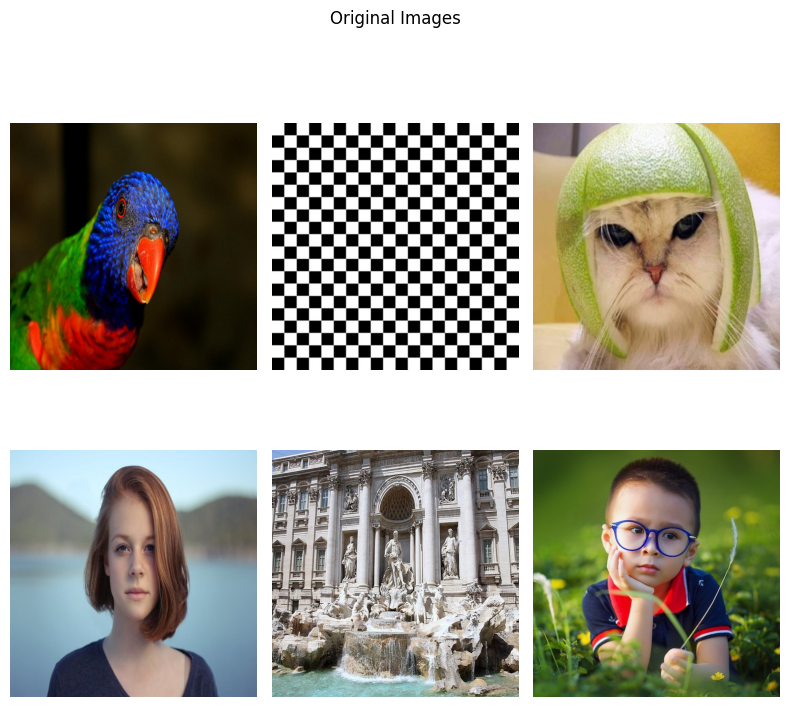

In [ ]:
show_image_grid(gt_images, 2, 3, 'Original Images', figsize=8)

### Gaussian Pyramid

In [ ]:
def pad_image_to_divisible(image, K, pad_value=0):
    # Get the original image dimensions
    h, w = image.shape[:2]

    # Calculate the padding needed for height and width
    pad_h = (K - (h % K)) % K  # Padding needed for height
    pad_w = (K - (w % K)) % K  # Padding needed for width

    # Compute the padding to add to top/bottom and left/right
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    # Pad the image: (top, bottom), (left, right), and (no padding on channels)
    if len(image.shape) == 3:  # For RGB images
        padded_image = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)),
                              mode='constant', constant_values=pad_value)
    else:  # For grayscale images
        padded_image = np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)),
                              mode='constant', constant_values=pad_value)

    return padded_image

In [ ]:
def gaussian_pyramid(image, levels):
    pyramid = [image]
    for i in range(levels - 1):
        # Apply Gaussian blur and downsample by a factor of 2

        # Write code here
        image = cv2.GaussianBlur(image,(5,5),sigmaX=1,sigmaY=1)
        image = image[::2,::2,:]

        image = pad_image_to_divisible(image, pyramid[0].shape[0])
        pyramid.append(image)

    return np.array(pyramid)

def opencv_resize(inp_image, levels):
    pyramid = []
    h, w    = inp_image.shape[:2]
    for i in range(levels):
        # Apply Gaussian blur and downsample by a factor of 2
        # Write code here
        image = cv2.GaussianBlur(inp_image,(5,5),sigmaX=1,sigmaY=1)
        image = cv2.resize(image, (h//2**i, w//2**i))

        image = pad_image_to_divisible(image, min(h, w))
        pyramid.append(image)

    return np.array(pyramid)

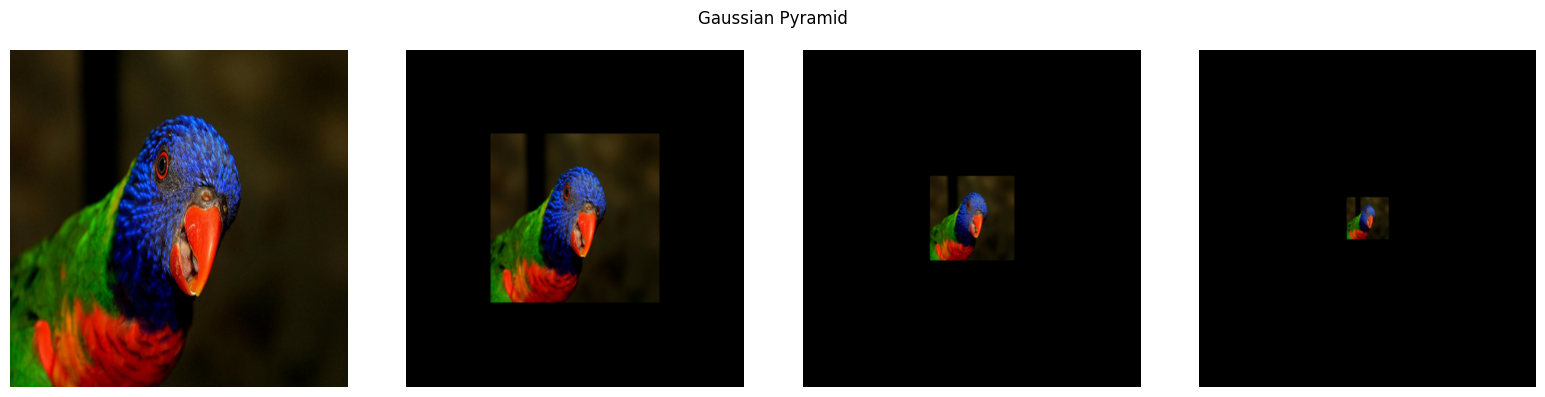

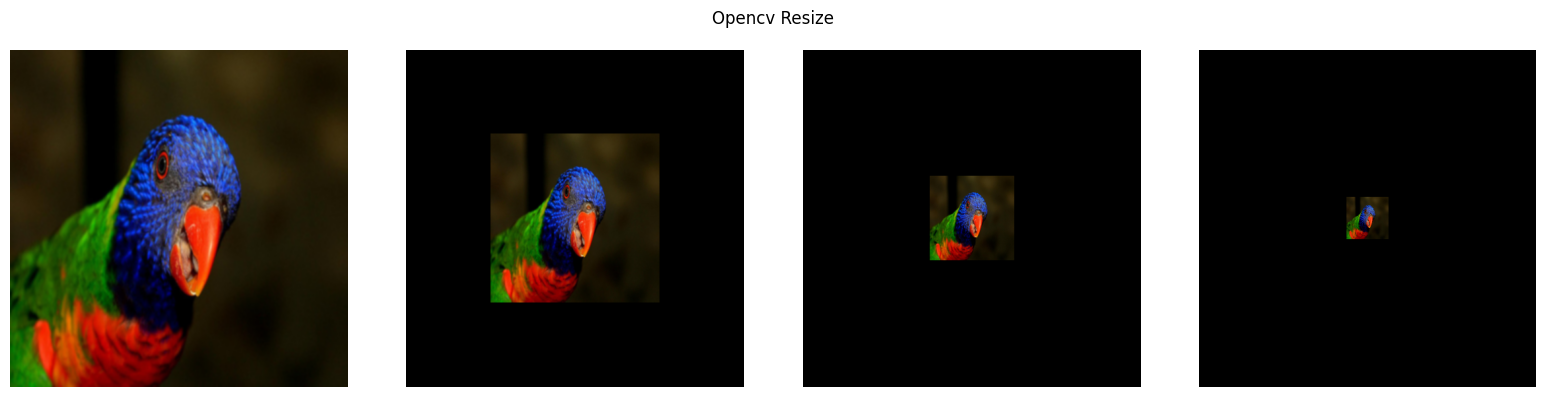

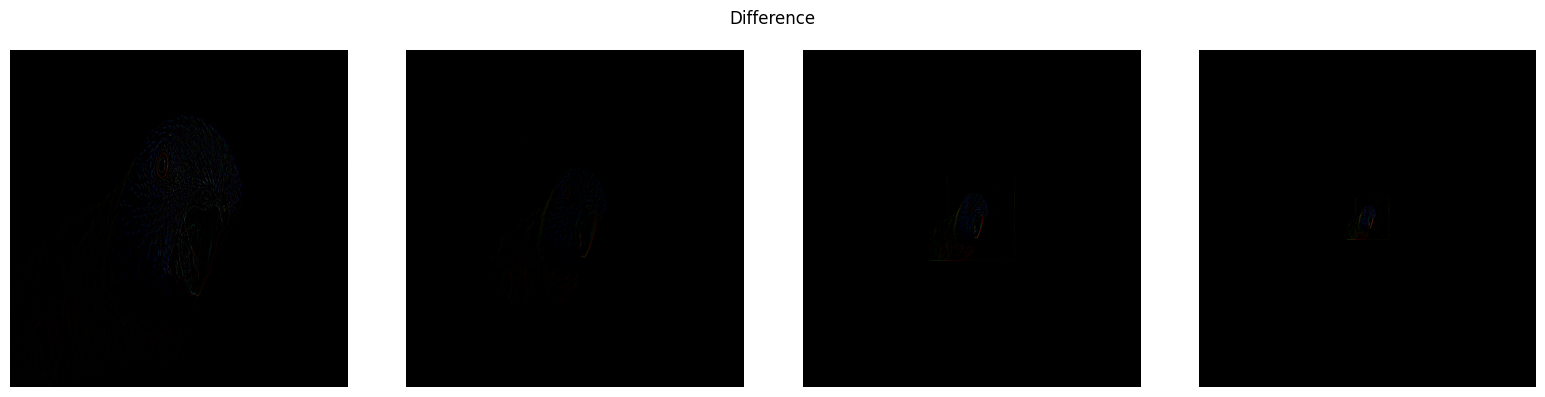

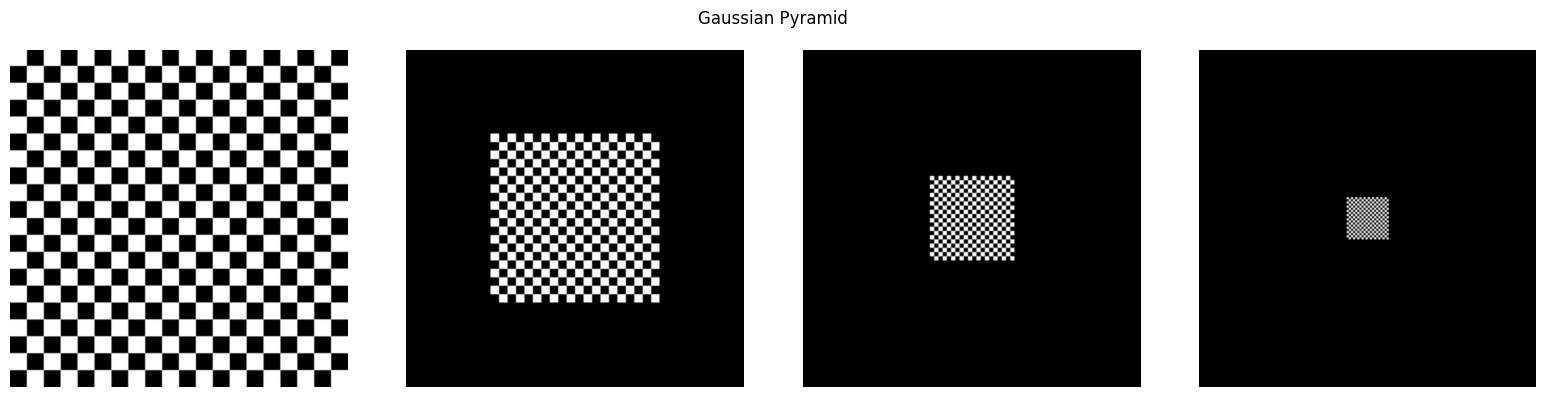

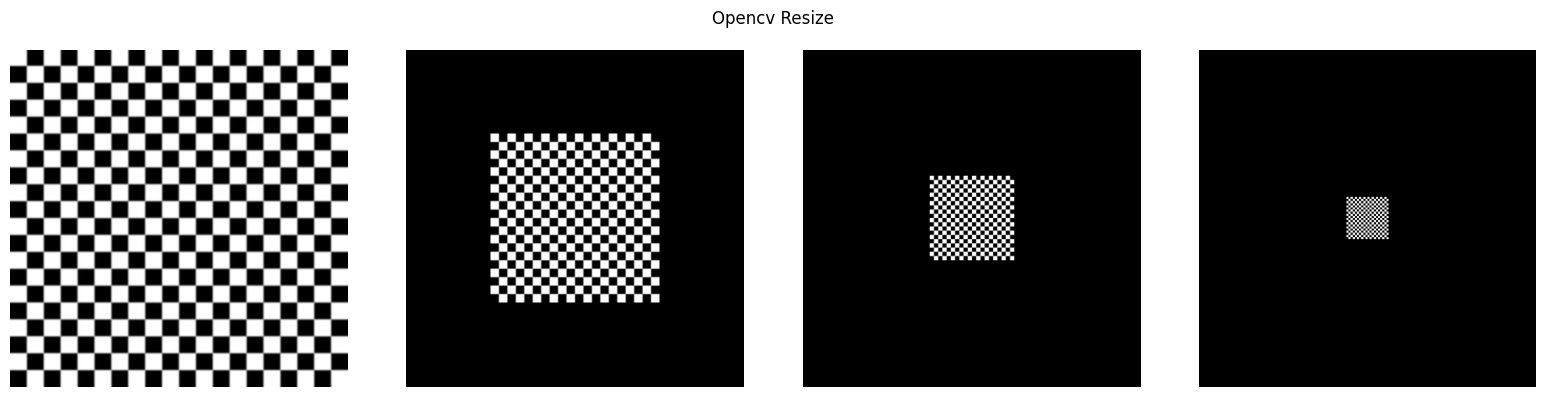

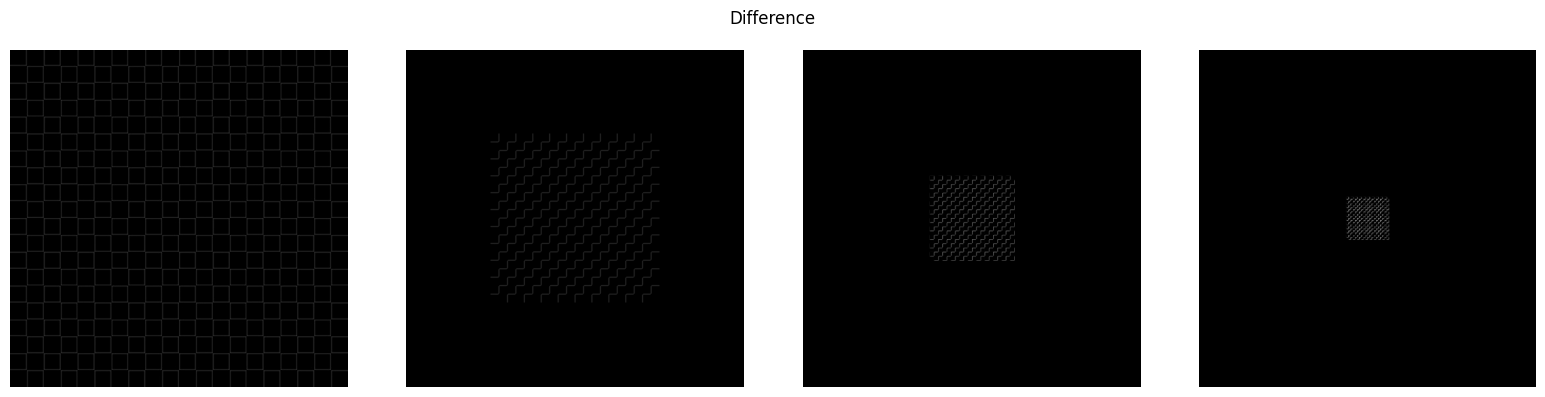

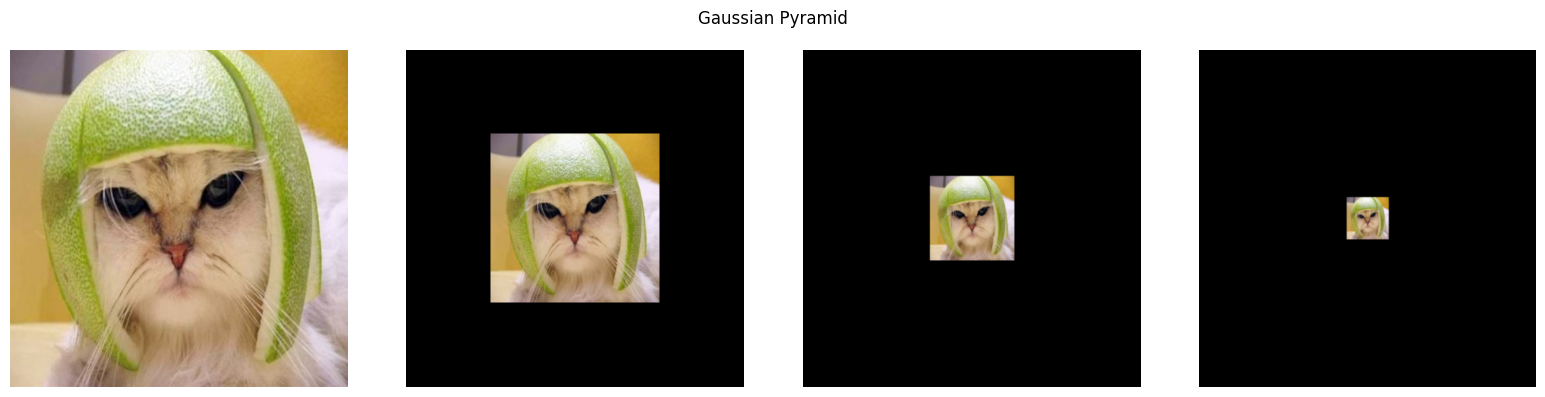

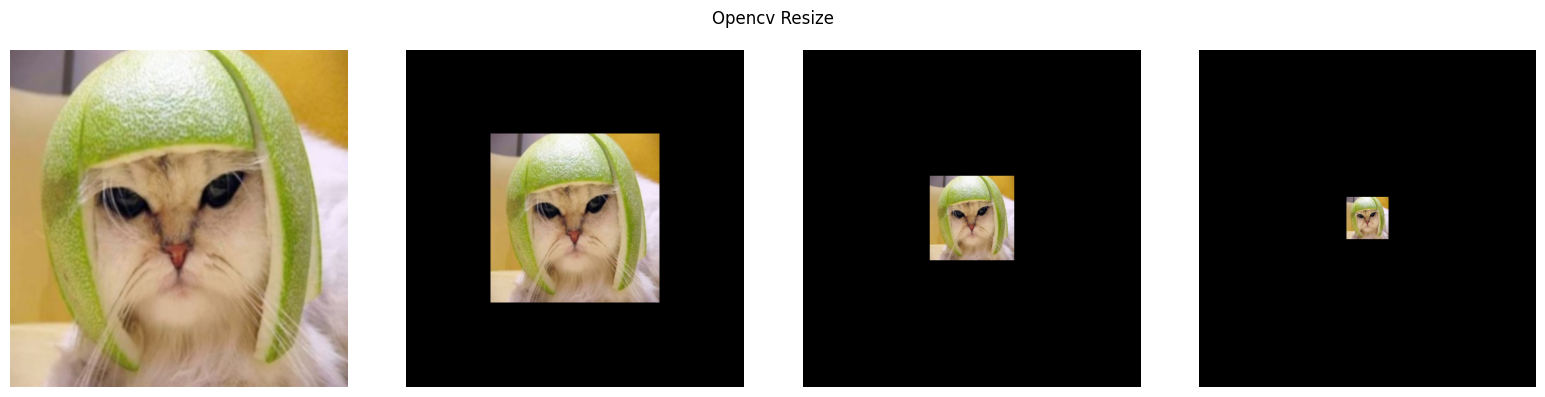

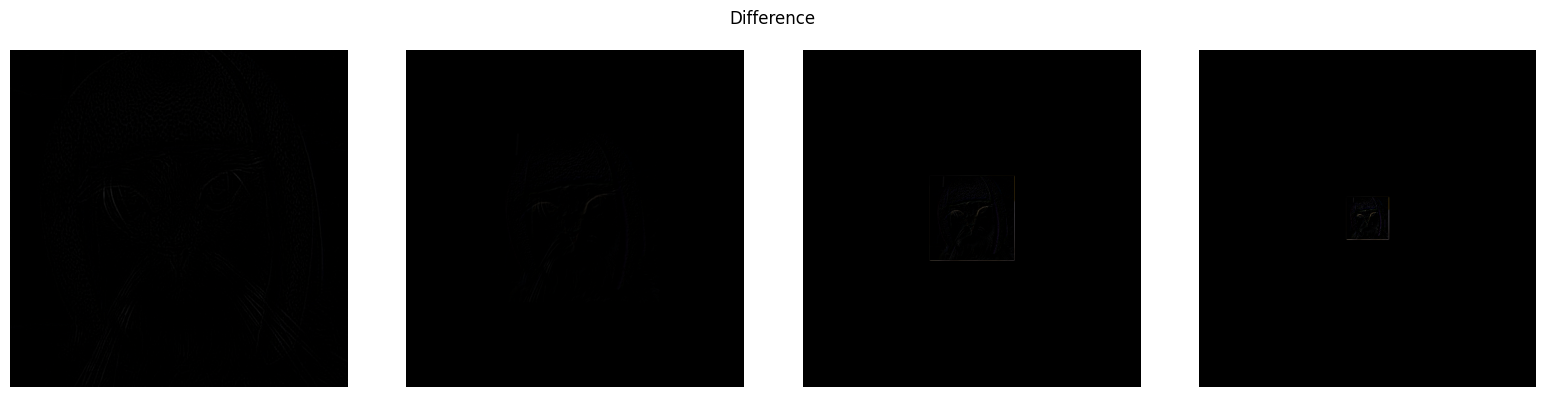

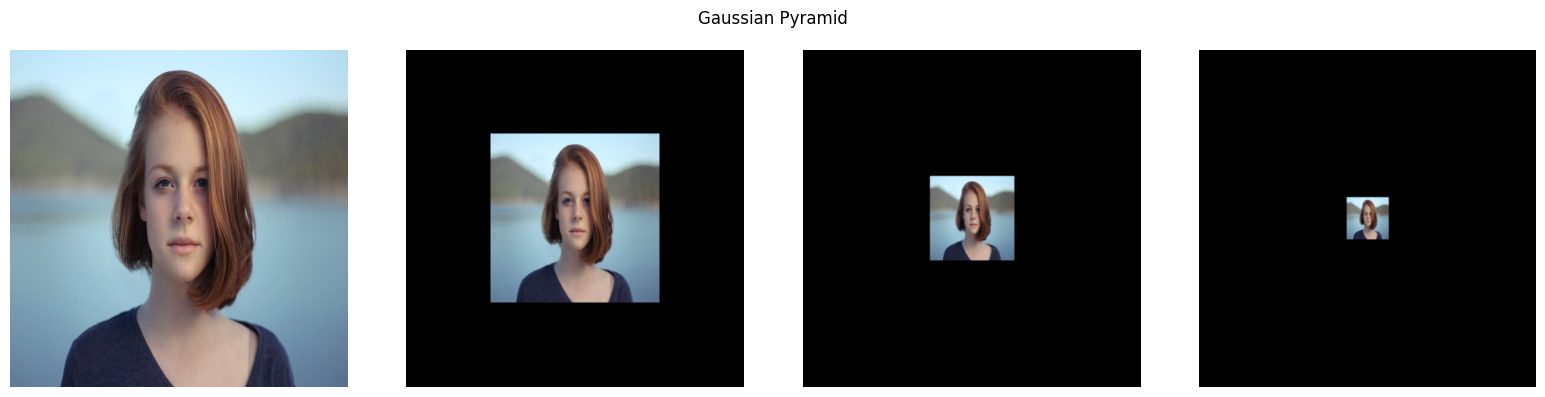

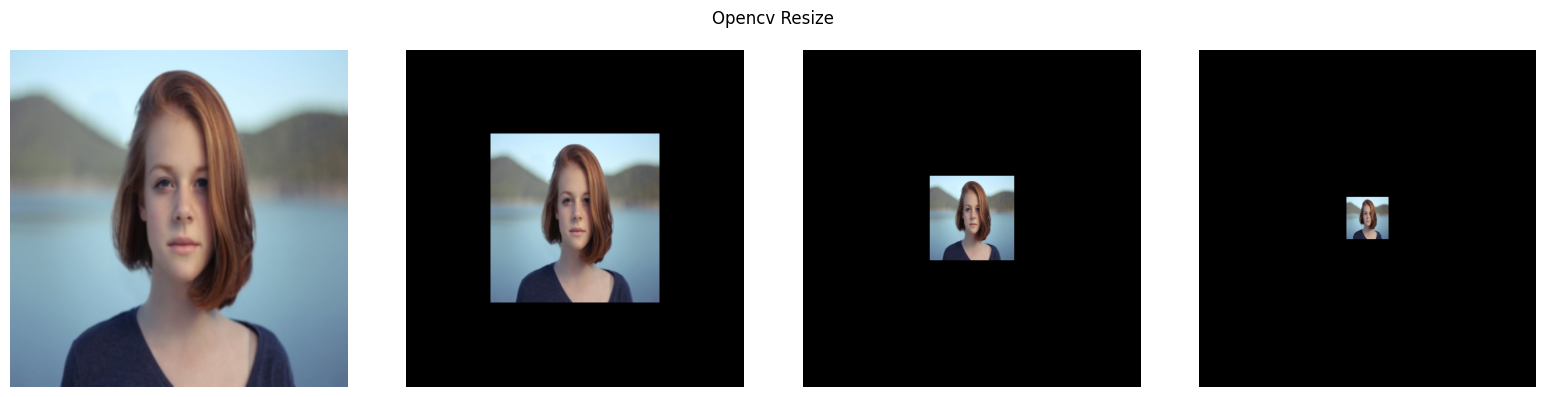

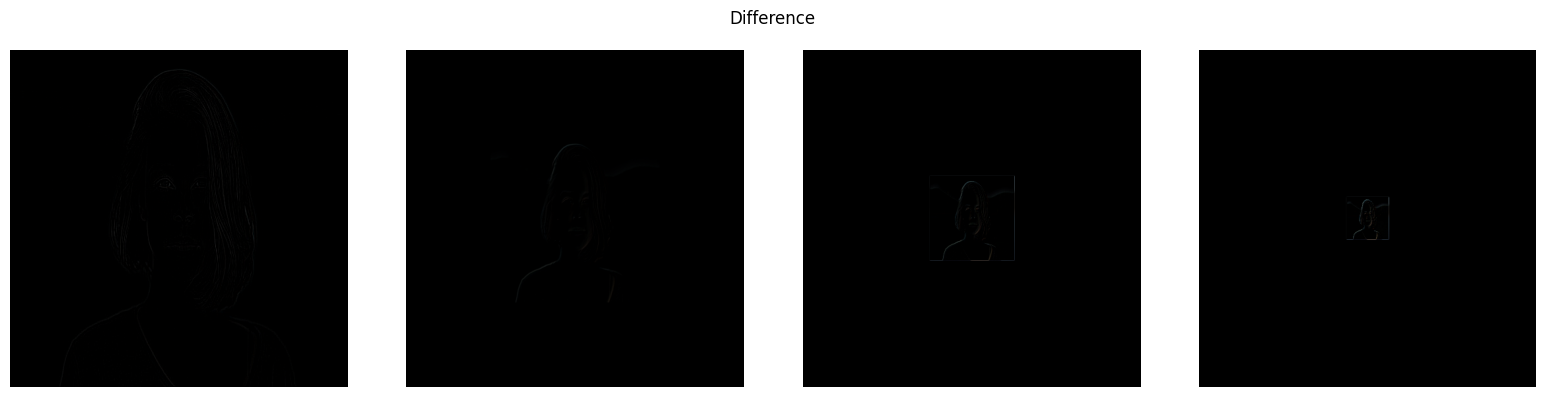

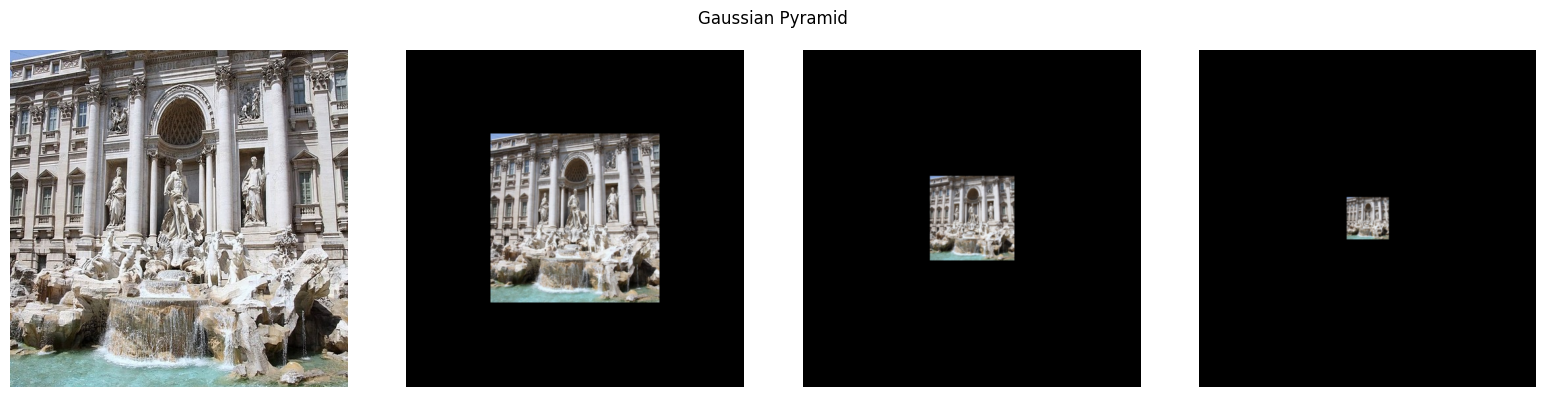

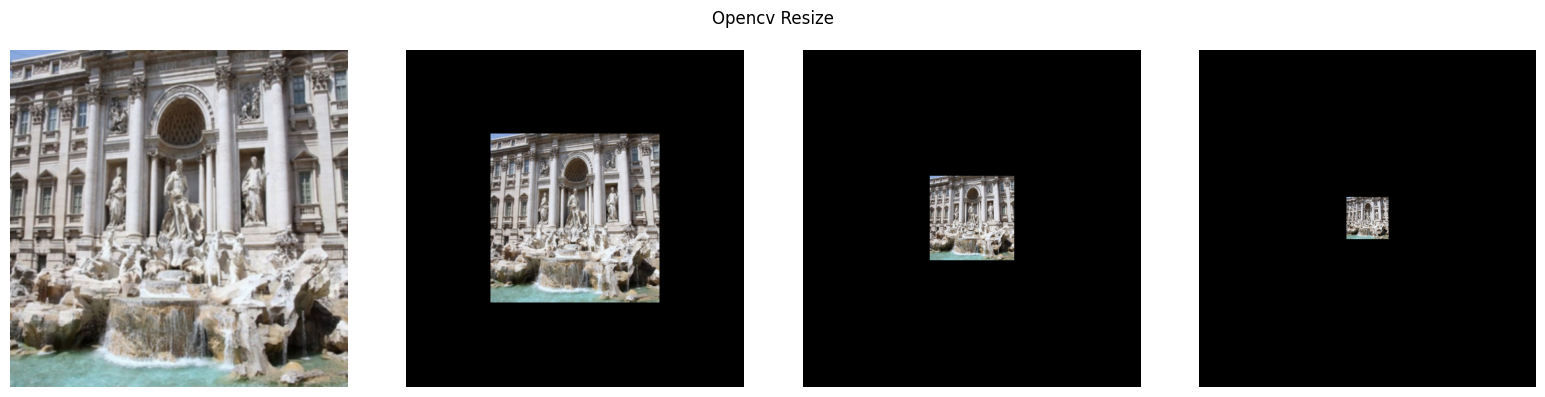

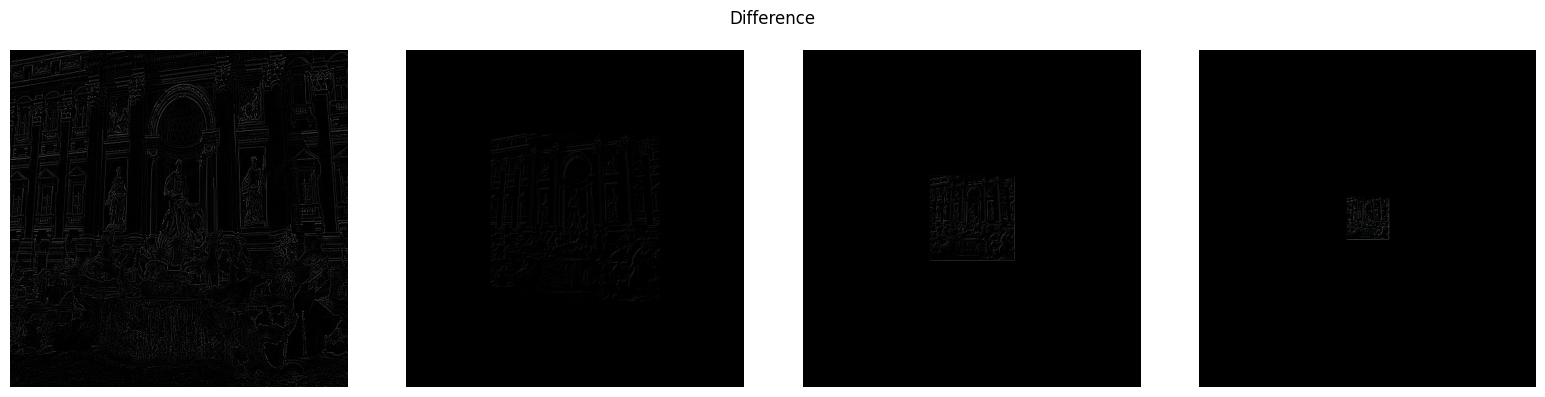

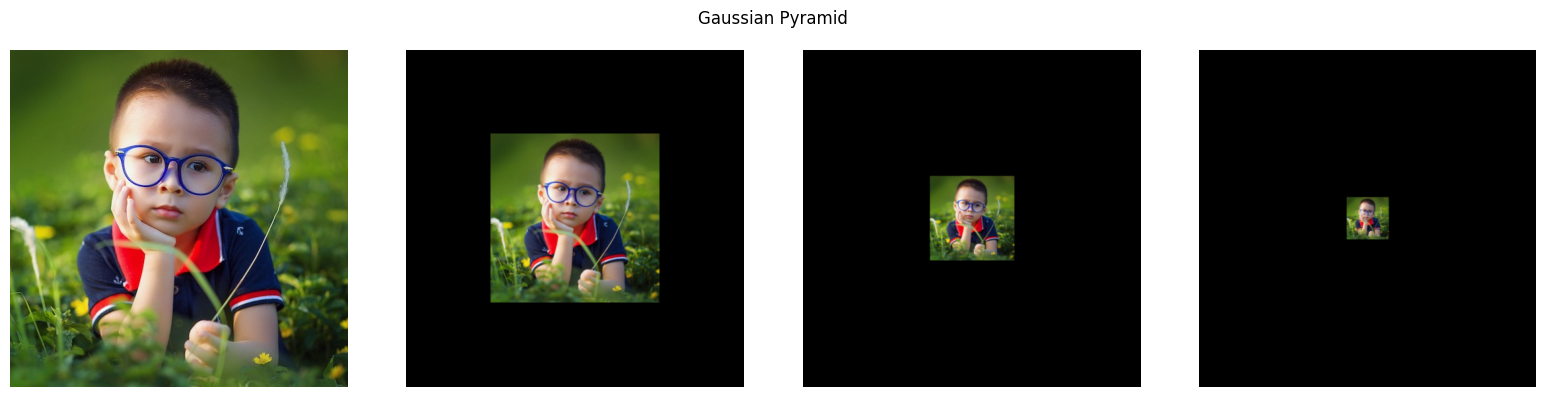

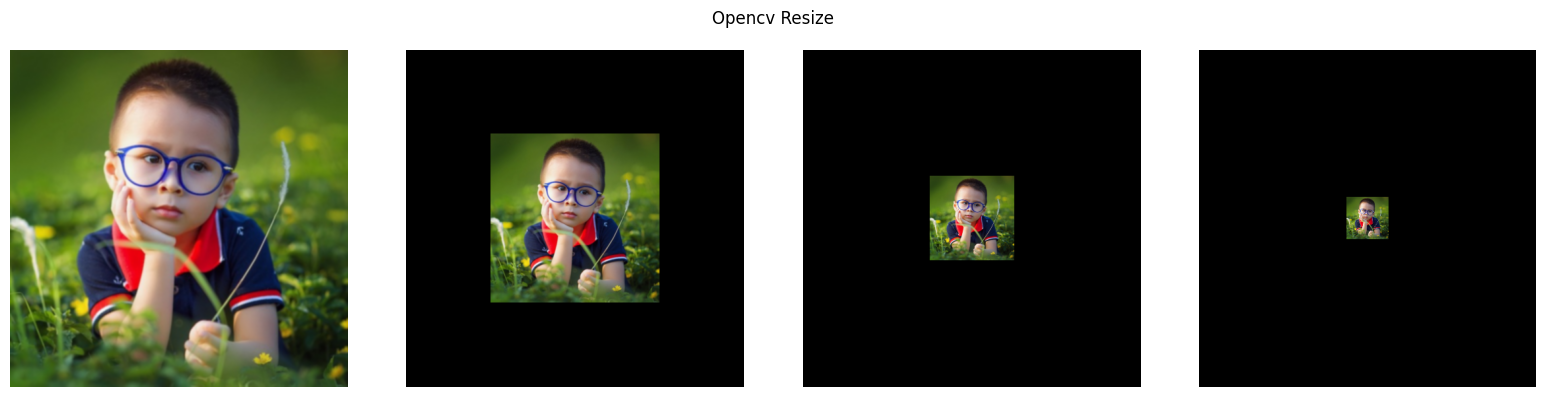

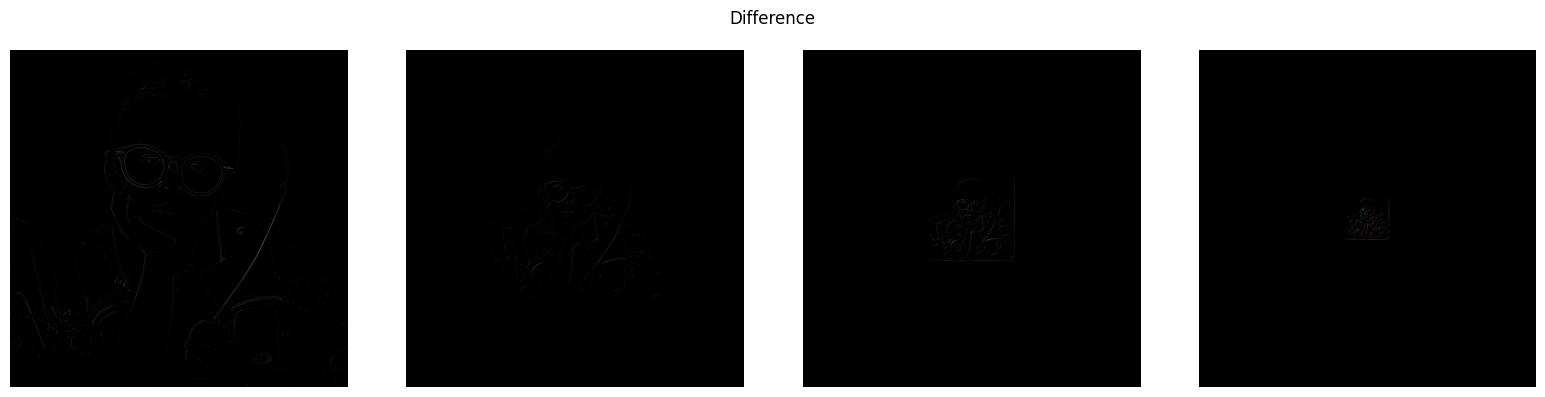

In [ ]:
for idx, image in enumerate(gt_images):

    # Generate pyramid of images for matching
    s_image_pyramids = gaussian_pyramid(image, levels=4)
    s_image_opecv_resize = opencv_resize(image, levels=4)

    diff = []
    for gauss_img, open_img in zip(s_image_pyramids, s_image_opecv_resize):
        diff.append(cv2.subtract(gauss_img, open_img))
    diff = np.array(diff)

    show_image_grid(s_image_pyramids, 1, 4, 'Gaussian Pyramid', figsize=16)
    show_image_grid(s_image_opecv_resize, 1, 4, 'Opencv Resize', figsize=16)
    show_image_grid(diff, 1, 4, 'Difference', figsize=16)

### Laplacian Blending

In [ ]:
def gaussian_pyramid(image, levels):

    gaussian_pyramid = [image]
    for i in range(levels):
        # blur
        image = cv2.GaussianBlur(image,(5,5),sigmaX=1,sigmaY=1)
        # subsample
        image = cv2.resize(image, (image.shape[1]//2, image.shape[0]//2))
        gaussian_pyramid.append(image)
    return gaussian_pyramid

def laplacian_pyramid(gaussian_pyramid):

    laplacian_pyramid = []
    for i in range(len(gaussian_pyramid) - 1):
        size = (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0])
        # upsample immediate successor in pyramid
        upsampled = cv2.resize(gaussian_pyramid[i + 1], size)
        # laplacian[i] = gaussian_pyramid[current] - gaussian_pyramid[upscaled successor of current]
        laplacian = cv2.subtract(gaussian_pyramid[i], upsampled)
        laplacian_pyramid.append(laplacian)
    laplacian_pyramid.append(gaussian_pyramid[-1])
    return laplacian_pyramid

def blend_pyramids(laplacian_pyramid_a, laplacian_pyramid_b):


    # mask: left half image a and right half image b
    rows, cols, _ = laplacian_pyramid_a[0].shape
    mask = np.zeros((rows, cols), dtype=np.float32)
    mask[:, cols // 2:] = 1.0
    mask = np.dstack([mask] * 3)

    # Building mask pyramid
    mask_pyramid = [mask]
    for i in range(1, len(laplacian_pyramid_a)):
        mask = cv2.GaussianBlur(mask,(5,5),sigmaX=1,sigmaY=1)
        mask = cv2.resize(mask, (laplacian_pyramid_a[i].shape[1], laplacian_pyramid_a[i].shape[0]))
        mask_pyramid.append(mask)

    # Blending laplacian pyramids using mask
    blended_pyramid = []
    for la, lb, mask in zip(laplacian_pyramid_a, laplacian_pyramid_b, mask_pyramid):
        blended = la * (1 - mask) + lb * mask
        blended_pyramid.append(blended)

    return blended_pyramid

def blended_pyramid_to_blended_image(laplacian_pyramid):

    image = laplacian_pyramid[-1]
    # Collapsing the pyramid to reconstruct blended image
    for i in range(len(laplacian_pyramid) - 2, -1, -1):
        size = (laplacian_pyramid[i].shape[1], laplacian_pyramid[i].shape[0])
        image = cv2.add(cv2.resize(image, size), laplacian_pyramid[i])
    # image = ( image - image.min / image.max - image.min ) * 255
    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    image = image.astype(np.uint8)

    return image

def laplacian_pyramid_blend_images(image_a, image_b, levels=6):

    ############ 1. Building Gaussian pyramids for both images ##########
    gaussian_pyramid_a = gaussian_pyramid(image_a, levels)
    gaussian_pyramid_b = gaussian_pyramid(image_b, levels)

    ############ 2. Building Laplacian pyramids for both images ########
    laplacian_pyramid_a = laplacian_pyramid(gaussian_pyramid_a)
    laplacian_pyramid_b = laplacian_pyramid(gaussian_pyramid_b)

    ############ 3. Blending the Laplacian pyramids ####################
    blended_pyramid = blend_pyramids(laplacian_pyramid_a, laplacian_pyramid_b)

    ########### 4. Reconstruct the blended image #######################
    blended_image = blended_pyramid_to_blended_image(blended_pyramid)

    return blended_image

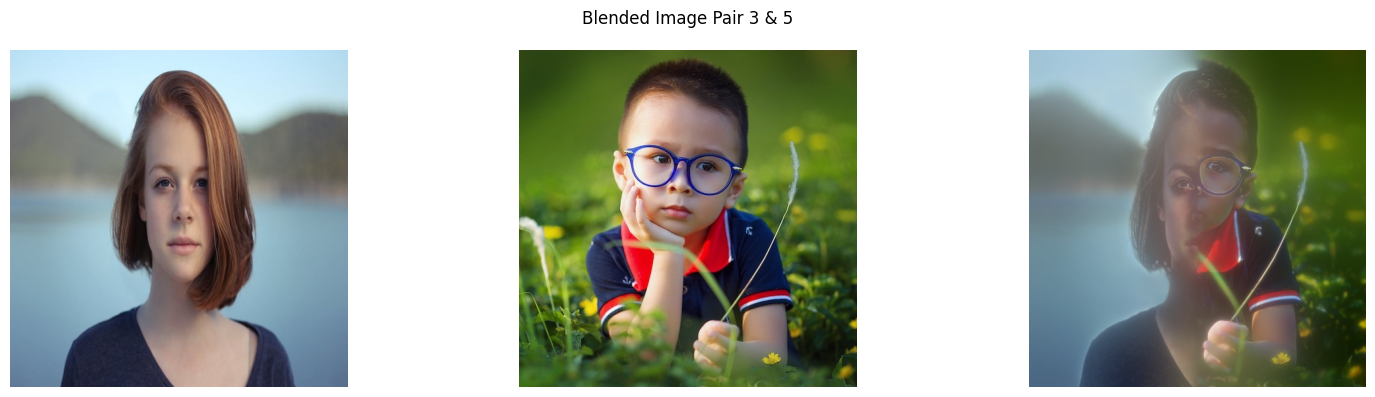

In [ ]:
blended_image = laplacian_pyramid_blend_images(gt_images[3], gt_images[5])
collage = np.array([gt_images[3], gt_images[5], blended_image])
show_image_grid(collage, 1, 3, 'Blended Image Pair 3 & 5', figsize=16)

### Harris Corner Detector


In [ ]:
def detect_harris_corner(image, k=0.04, threshold=0.01):
    # Convert image to grayscale
    if len(image.shape) == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    else:
        gray_image = image.astype(np.float32) / 255.0

    ############# 1. computing Ix and Iy
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float32)
    Ix = cv2.filter2D(gray_image, -1, sobel_x)
    Iy = cv2.filter2D(gray_image, -1, sobel_y)

    ############# 2. M: Ixx, Ixy, Iyy
    Ixx = Ix * Ix
    Iyy = Iy * Iy
    Ixy = Ix * Iy

    ############# 3. blur
    Sxx = cv2.GaussianBlur(Ixx, (5, 5), sigmaX=1.0)
    Syy = cv2.GaussianBlur(Iyy, (5, 5), sigmaX=1.0)
    Sxy = cv2.GaussianBlur(Ixy, (5, 5), sigmaX=1.0)

    ############## 4. R
    det = (Sxx * Syy) - (Sxy ** 2)
    trace = Sxx + Syy
    R = det - k * (trace ** 2)

    ############# 5. thresholding based on R
    thresholded_image = np.zeros_like(R)
    thresholded_image[R > threshold * R.max()] = 1

    ############## 6. nonmaximal suppression

    rows, cols = thresholded_image.shape[:2]
    corner_image = np.zeros_like(thresholded_image)
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):

            neighborhood = thresholded_image[i - 1:i + 2, j - 1:j + 2]
            if thresholded_image[i, j] == np.max(neighborhood):
                corner_image[i, j] = thresholded_image[i, j]

    # normalize
    corner_image = (corner_image * 255).astype(np.uint8)
    corner_image = corner_image.astype(np.uint8)


    return corner_image

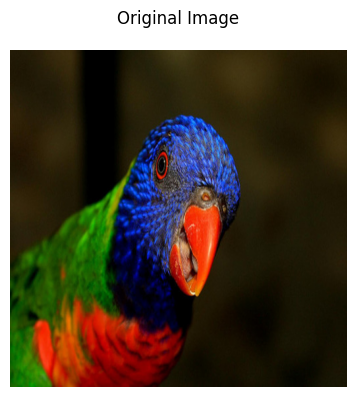

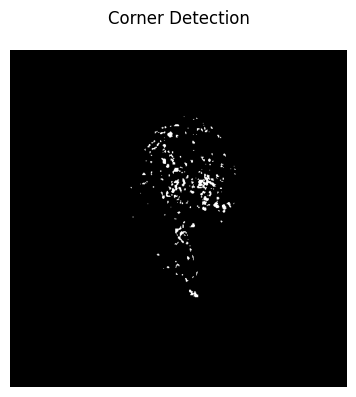

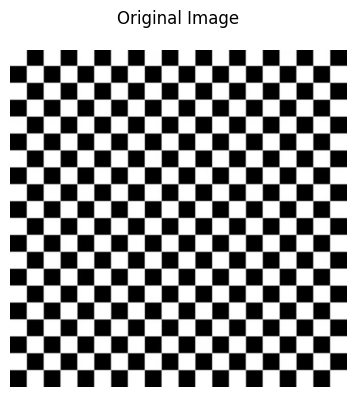

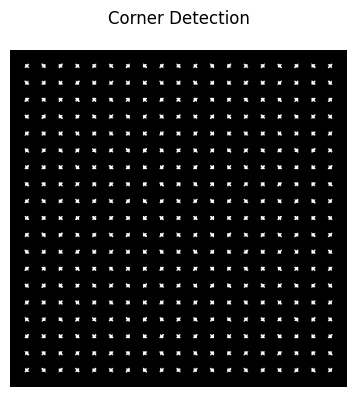

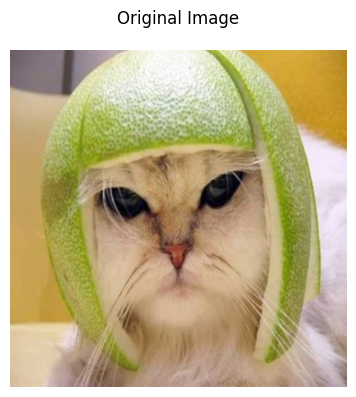

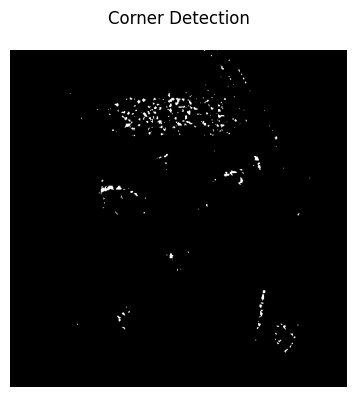

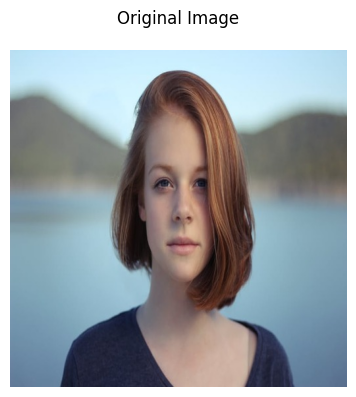

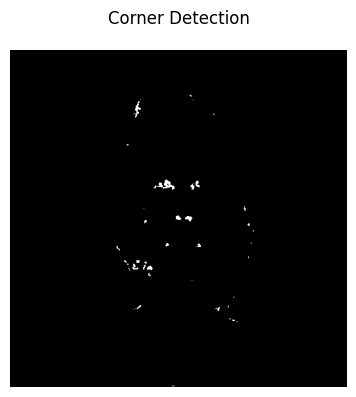

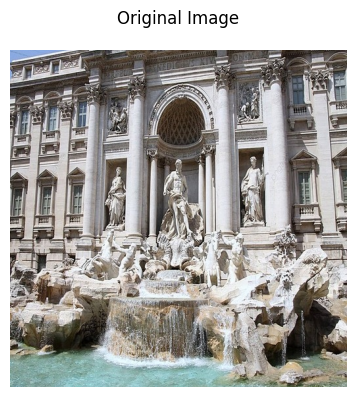

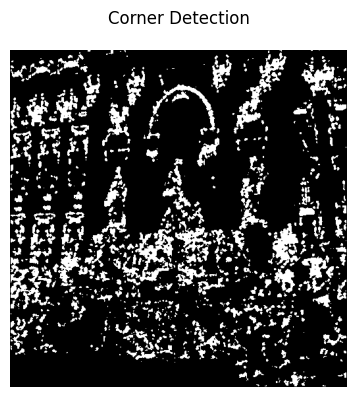

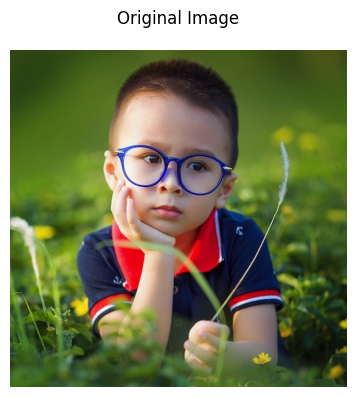

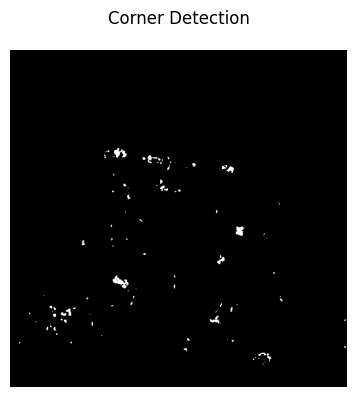

In [ ]:
for image in gt_images:
    corner_image = detect_harris_corner(image)
    show_image_grid(image, 1, 1, 'Original Image', figsize=16)
    show_image_grid(corner_image, 1, 1, 'Corner Detection', figsize=16)

### Hessian Corner Detector

In [ ]:
def detect_hessian_corner(image, threshold=0.01):
    # Convert image to grayscale
    if len(image.shape) == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    else:
        gray_image = image.astype(np.float32) / 255.0

    ######### 1. Hessian
    hessian_xx = np.array([[1, -2, 1], [0, 0, 0], [-1, 2, -1]], dtype=np.float32)
    hessian_yy = np.array([[1, 0, -1], [-2, 0, 2], [1, 0, -1]], dtype=np.float32)
    hessian_xy = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)
    Ixx = cv2.filter2D(gray_image, -1, hessian_xx)
    Iyy = cv2.filter2D(gray_image, -1, hessian_yy)
    Ixy = cv2.filter2D(gray_image, -1, hessian_xy)

    ########## 2. R = det (H)
    R = Ixx * Iyy - Ixy ** 2

    ############# 3. thresholding based on R
    thresholded_image = np.zeros_like(R)
    thresholded_image[R > threshold * R.max()] = 1

    ############## 4. nonmaximal suppression

    rows, cols = thresholded_image.shape[:2]
    corner_image = np.zeros_like(thresholded_image)
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):

            neighborhood = thresholded_image[i - 1:i + 2, j - 1:j + 2]
            if thresholded_image[i, j] == np.max(neighborhood):
                corner_image[i, j] = thresholded_image[i, j]

    # normalize
    corner_image = (corner_image * 255).astype(np.uint8)
    corner_image = corner_image.astype(np.uint8)

    return corner_image


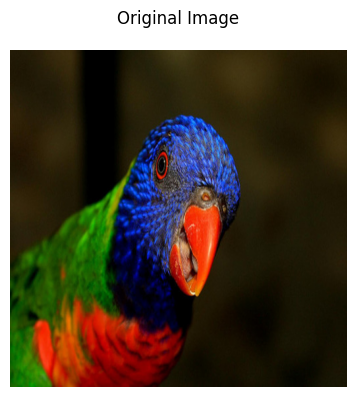

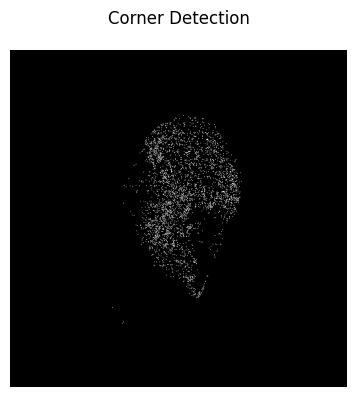

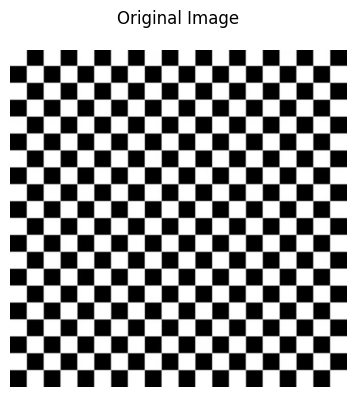

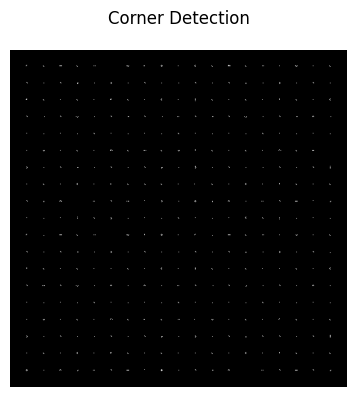

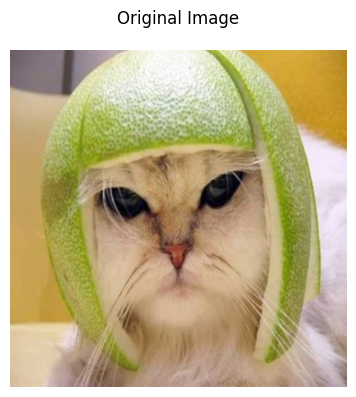

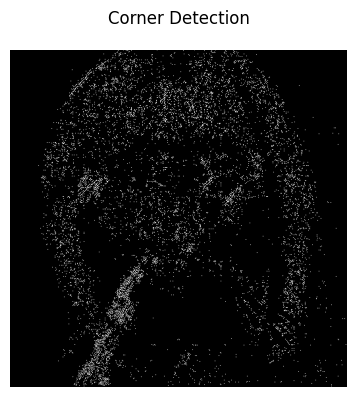

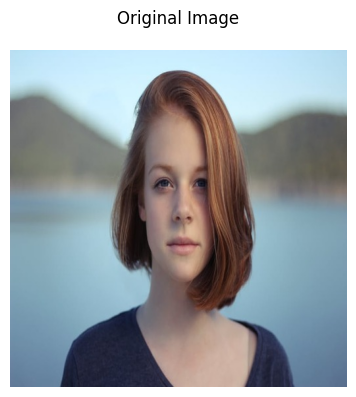

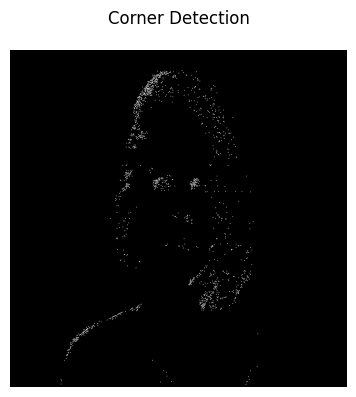

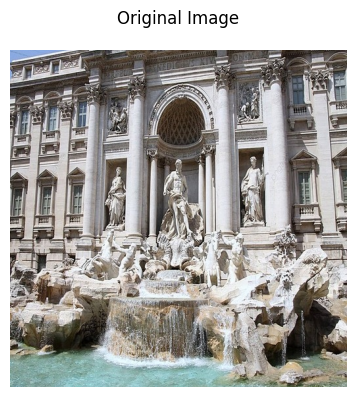

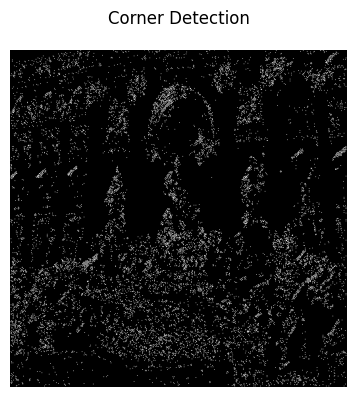

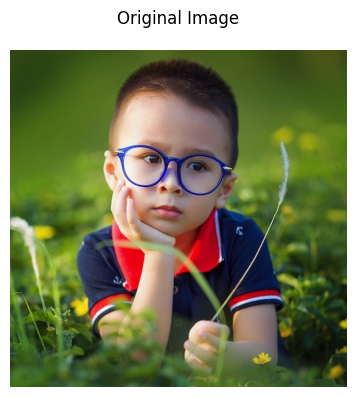

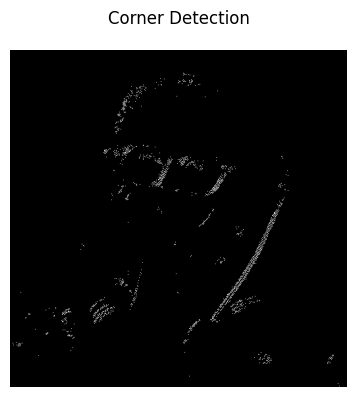

In [ ]:
for image in gt_images:
    corner_image = detect_hessian_corner(image)
    show_image_grid(image, 1, 1, 'Original Image', figsize=16)
    show_image_grid(corner_image, 1, 1, 'Corner Detection', figsize=16)